<a href="https://colab.research.google.com/github/BardRimon/Study/blob/main/CV/HW2_ImageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Домашняя работа №2

MobileNet-V2 (2018)

In [1]:
# ! pip install torchsummary


In [2]:
import torch
import torchvision.models as models

# Download the MobileNetV2 model with pre-trained weights
mobilenet_v2 = models.mobilenet_v2(weights='IMAGENET1K_V1')

# You can now use the 'mobilenet_v2' model for various tasks.
# For example, to see the model architecture:
# print(mobilenet_v2)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 74.5MB/s]


In [3]:
! pip install torchinfo
from torchinfo import summary
summary(mobilenet_v2, input_size=(1, 3, 224, 224))  # 1 - размер батча

Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV2                                        [1, 1000]                 --
├─Sequential: 1-1                                  [1, 1280, 7, 7]           --
│    └─Conv2dNormActivation: 2-1                   [1, 32, 112, 112]         --
│    │    └─Conv2d: 3-1                            [1, 32, 112, 112]         864
│    │    └─BatchNorm2d: 3-2                       [1, 32, 112, 112]         64
│    │    └─ReLU6: 3-3                             [1, 32, 112, 112]         --
│    └─InvertedResidual: 2-2                       [1, 16, 112, 112]         --
│    │    └─Sequential: 3-4                        [1, 16, 112, 112]         896
│    └─InvertedResidual: 2-3                       [1, 24, 56, 56]           --
│    │    └─Sequential: 3-5                        [1, 24, 56, 56]           5,136
│    └─InvertedResidual: 2-4                       [1, 24, 56, 56]           --
│    │    └─Sequential: 3-6   

Информация о модели взята от сюда: https://arxiv.org/pdf/1801.04381#page=3.08


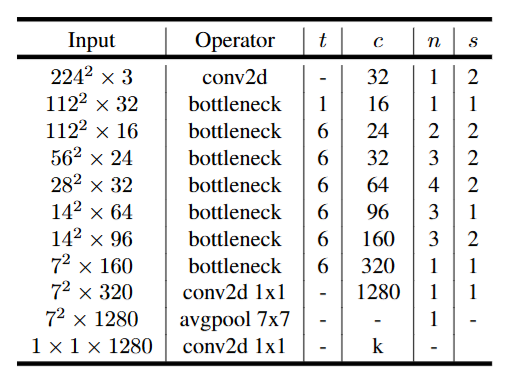

Возможные полезные штучки
https://github.com/tonylins/pytorch-mobilenet-v2/blob/master/README.md

In [4]:
import torch
import torch.nn as nn

class InvertedResidual(nn.Module):
    def __init__(self, in_channels, out_channels, stride, expand_ratio):
        super(InvertedResidual, self).__init__()
        self.stride = stride
        hidden_dim = int(round(in_channels * expand_ratio))
        self.use_res_connect = self.stride == 1 and in_channels == out_channels

        layers = []
        if expand_ratio != 1:
            # Расширяющая свертка 1x1 (pointwise)
            layers.append(nn.Conv2d(in_channels, hidden_dim, kernel_size=1, stride=1, padding=0, bias=False))
            layers.append(nn.BatchNorm2d(hidden_dim))
            layers.append(nn.ReLU6(inplace=True))

        # Глубинная свертка 3x3 (depthwise)
        layers.extend([
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, stride=stride, padding=1, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),
        ])

        # Сжимающая свертка 1x1 (pointwise) с линейной активацией
        layers.extend([
            nn.Conv2d(hidden_dim, out_channels, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(out_channels),
        ])

        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.conv(x)
        else:
            return self.conv(x)


class MobileNetV2(nn.Module):
    def __init__(self, num_classes=1000, width_mult=1.0):
        super(MobileNetV2, self).__init__()
        block = InvertedResidual
        input_channel = 32
        last_channel = 1280

        # Таблица конфигурации для блоков MobileNetV2
        # t: expand_ratio, c: out_channels, n: num_blocks, s: stride
        inverted_residual_setting = [
            [1, 16, 1, 1],
            [6, 24, 2, 2],
            [6, 32, 3, 2],
            [6, 64, 4, 2],
            [6, 96, 3, 1],
            [6, 160, 3, 2],
            [6, 320, 1, 1],
        ]

        # Начальный сверточный слой
        input_channel = int(input_channel * width_mult)
        self.last_channel = int(last_channel * max(1.0, width_mult))
        features = [
            nn.Conv2d(3, input_channel, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(input_channel),
            nn.ReLU6(inplace=True),
        ]

        # Создание последовательности инвертированных остаточных блоков
        for t, c, n, s in inverted_residual_setting:
            output_channel = int(c * width_mult)
            for i in range(n):
                stride = s if i == 0 else 1
                features.append(block(input_channel, output_channel, stride, expand_ratio=t))
                input_channel = output_channel

        # Последние слои перед классификацией
        features.append(nn.Conv2d(input_channel, self.last_channel, kernel_size=1, stride=1, padding=0, bias=False))
        features.append(nn.BatchNorm2d(self.last_channel))
        features.append(nn.ReLU6(inplace=True))

        self.features = nn.Sequential(*features)

        # Классификационная часть
        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(self.last_channel, num_classes),
        )

        # Инициализация весов
        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = x.mean([2, 3])  # Глобальный усредняющий пулинг
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

# Пример создания модели

model = MobileNetV2(num_classes=3)
# print(model)

#     # Пример входного тензора
#     input_tensor = torch.randn(1, 3, 224, 224)
#     output = model(input_tensor)
#     print("Размер выходного тензора:", output.shape)

In [5]:
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
MobileNetV2                              [1, 3]                    --
├─Sequential: 1-1                        [1, 1280, 7, 7]           --
│    └─Conv2d: 2-1                       [1, 32, 112, 112]         864
│    └─BatchNorm2d: 2-2                  [1, 32, 112, 112]         64
│    └─ReLU6: 2-3                        [1, 32, 112, 112]         --
│    └─InvertedResidual: 2-4             [1, 16, 112, 112]         --
│    │    └─Sequential: 3-1              [1, 16, 112, 112]         896
│    └─InvertedResidual: 2-5             [1, 24, 56, 56]           --
│    │    └─Sequential: 3-2              [1, 24, 56, 56]           5,136
│    └─InvertedResidual: 2-6             [1, 24, 56, 56]           --
│    │    └─Sequential: 3-3              [1, 24, 56, 56]           8,832
│    └─InvertedResidual: 2-7             [1, 32, 28, 28]           --
│    │    └─Sequential: 3-4              [1, 32, 28, 28]           10,000
│  

Но обучать 1000 классов очень займёт слишком большое время, так что изменим модель, чтобы она классифицировала 3 класса

In [6]:
# Установка kaggle и импорт необходимых модулей
from google.colab import drive
import os

# Монтируем Google Drive в Colab
drive.mount('/content/drive')

# Путь к kaggle.json на Google Drive (укажите путь к своему файлу)
kaggle_json_path = '/content/drive/MyDrive/Colab Notebooks/kaggle.json' ##### ВОТ ТУТ МЕНЯТЬ ПУТЬ К KAGGLE.JSON

# Создаем папку .kaggle в домашней директории и копируем файл туда
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
!cp "{kaggle_json_path}" ~/.kaggle/kaggle.json

# Меняем права доступа к файлу
!chmod 600 ~/.kaggle/kaggle.json

# Проверяем, что всё работает, показывая список датасетов (можно потом заменить командой скачивания)
!kaggle datasets list

Mounted at /content/drive
ref                                                            title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
ahmeduzaki/global-earthquake-tsunami-risk-assessment-dataset   Global Earthquake-Tsunami Risk Assessment Dataset        16151  2025-10-01 16:35:53.273000          15179        515  1.0              
jockeroika/life-style-data                                     Life Style Data                                        3995645  2025-10-14 13:50:45.303000          17871        365  0.8235294        
jaderz/hospital-beds-management                                Hospital Beds Management                                 47583  2025-10-03 09:21:58.590000          12404        31

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sanikamal/rock-paper-scissors-dataset")

print("Path to dataset files:", path)

100%|██████████| 452M/452M [00:12<00:00, 37.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sanikamal/rock-paper-scissors-dataset/versions/1


In [8]:
import os
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

# --- 1. Определение путей и параметров ---

# Основной путь к датасету
BASE_PATH = '/root/.cache/kagglehub/datasets/sanikamal/rock-paper-scissors-dataset/versions/1/Rock-Paper-Scissors'

# Пути к папкам с данными
# Нам больше не нужна отдельная папка для валидации
train_dir = os.path.join(BASE_PATH, 'train')
test_dir = os.path.join(BASE_PATH, 'test')

# Параметры
BATCH_SIZE = 32
IMG_SIZE = (224, 224) # Размер изображений для MobileNetV2
VALIDATION_SPLIT = 0.2 # Доля данных, которая пойдет на валидацию (20%)


# --- 2. Создание трансформаций ---

# Трансформации для обучающего набора данных (с аугментацией)
train_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Трансформации для валидационного и тестового наборов (без аугментации)
val_test_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# --- 3. Создание кастомного класса Dataset (остается без изменений) ---

class RockPaperScissorsDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.class_to_idx = {'rock': 0, 'paper': 1, 'scissors': 2}
        self.idx_to_class = {v: k for k, v in self.class_to_idx.items()}
        self.samples = self._make_dataset()

    def _make_dataset(self):
        samples = []
        for class_name in sorted(self.class_to_idx.keys()):
            class_dir = os.path.join(self.root_dir, class_name)
            if not os.path.isdir(class_dir):
                continue

            class_idx = self.class_to_idx[class_name]
            for filename in os.listdir(class_dir):
                if filename.endswith(('.png', '.jpg', '.jpeg')):
                    path = os.path.join(class_dir, filename)
                    item = (path, class_idx)
                    samples.append(item)
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

# --- 4. Создание и разделение датасетов ---

# Сначала создаем один большой "тренировочный" датасет
# Важно: пока что применяем к нему train_transforms
full_train_dataset = RockPaperScissorsDataset(root_dir=train_dir, transform=train_transforms)

# Рассчитываем размеры для разделения
total_size = len(full_train_dataset)
val_size = int(total_size * VALIDATION_SPLIT)
train_size = total_size - val_size

# Разделяем датасет на обучающий и валидационный
# torch.manual_seed для воспроизводимости разделения
torch.manual_seed(42)
train_subset, val_subset = random_split(full_train_dataset, [train_size, val_size])

# ВАЖНО: для валидационного набора данных нужно использовать трансформации без аугментации.
# Мы обращаемся к внутреннему датасету подмножества и меняем его свойство transform.
val_subset.dataset.transform = val_test_transforms

# Создаем тестовый датасет как и раньше
test_dataset = RockPaperScissorsDataset(root_dir=test_dir, transform=val_test_transforms)


# --- 5. Создание DataLoader'ов ---

# Создаем загрузчики из наших новых подмножеств (subset)
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)



print(f"Общий размер исходного обучающего набора: {len(full_train_dataset)}")
print("-" * 30)
print(f"Размер нового обучающего набора (80%): {len(train_subset)}")
print(f"Размер нового валидационного набора (20%): {len(val_subset)}")
print(f"Размер тестового набора: {len(test_dataset)}")
print("-" * 30)

# Получим по одному батчу для проверки
train_images, train_labels = next(iter(train_loader))
val_images, val_labels = next(iter(val_loader))

print(f"Размер батча из train_loader: {train_images.shape}")
print(f"Размер батча из val_loader: {val_images.shape}")
print(f"Классы: {full_train_dataset.class_to_idx}")


Общий размер исходного обучающего набора: 2520
------------------------------
Размер нового обучающего набора (80%): 2016
Размер нового валидационного набора (20%): 504
Размер тестового набора: 372
------------------------------
Размер батча из train_loader: torch.Size([32, 3, 224, 224])
Размер батча из val_loader: torch.Size([32, 3, 224, 224])
Классы: {'rock': 0, 'paper': 1, 'scissors': 2}


Используемое устройство: cuda

Начало обучения...

--- Эпоха 1/5 ---


Eval: 100%|██████████| 16/16 [00:02<00:00,  7.20it/s, acc=0.3611, loss=4.06]



Результаты эпохи 1:
  Train Loss: 0.2990, Train Acc: 0.8651
  Val Loss:   4.5632, Val Acc:   0.3611

--- Эпоха 2/5 ---


Eval: 100%|██████████| 16/16 [00:02<00:00,  7.26it/s, acc=0.9504, loss=0.151]



Результаты эпохи 2:
  Train Loss: 0.0505, Train Acc: 0.9816
  Val Loss:   0.1444, Val Acc:   0.9504

--- Эпоха 3/5 ---


...


Результаты эпохи 3:
  Train Loss: 0.0195, Train Acc: 0.9945
  Val Loss:   1.0318, Val Acc:   0.7044

--- Эпоха 4/5 ---


Eval: 100%|██████████| 16/16 [00:02<00:00,  7.05it/s, acc=0.9980, loss=0.00567]



Результаты эпохи 4:
  Train Loss: 0.0106, Train Acc: 0.9955
  Val Loss:   0.0089, Val Acc:   0.9980

--- Эпоха 5/5 ---


Eval: 100%|██████████| 16/16 [00:02<00:00,  7.30it/s, acc=1.0000, loss=6.41e-5]



Результаты эпохи 5:
  Train Loss: 0.0021, Train Acc: 1.0000
  Val Loss:   0.0001, Val Acc:   1.0000

Обучение завершено!


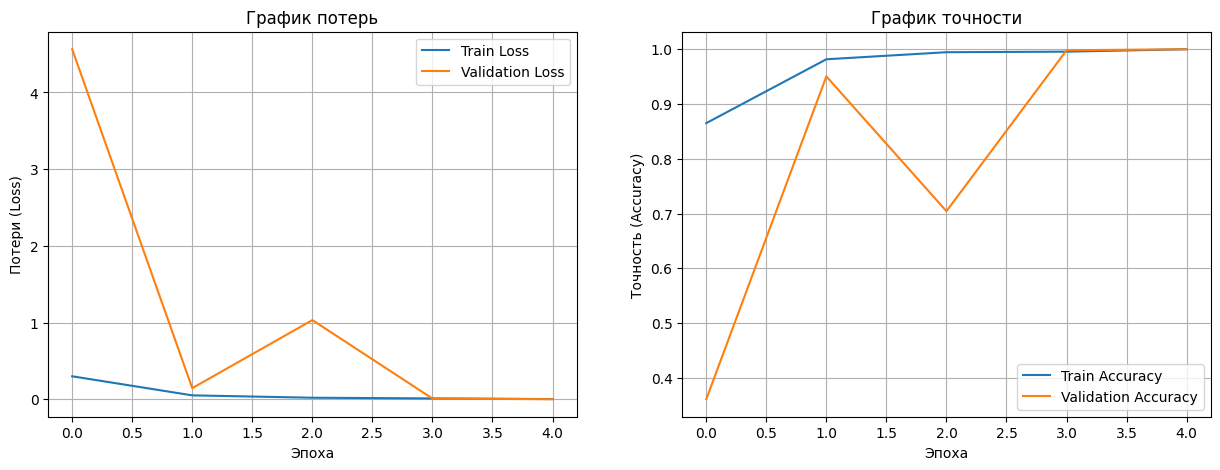


Начало финальной оценки на тестовых данных...


Eval: 100%|██████████| 12/12 [00:01<00:00,  6.90it/s, acc=0.8226, loss=0.0107]


Результаты на тестовом наборе:
  Test Loss: 0.6889
  Test Accuracy: 0.8226 (82.26%)


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. Настройка ---

# Выбираем устройство для вычислений (GPU, если доступен, иначе CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

# Инициализируем модель и перемещаем её на выбранное устройство
# num_classes=3, так как у нас 3 класса: rock, paper, scissors
model = MobileNetV2(num_classes=3).to(device)

# Определяем функцию потерь. CrossEntropyLoss подходит для задач многоклассовой классификации.
criterion = nn.CrossEntropyLoss()

# Определяем оптимизатор. Adam - хороший выбор по умолчанию.
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Количество эпох обучения
NUM_EPOCHS = 5


# --- 2. Функция для одной эпохи обучения ---

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  # Переводим модель в режим обучения
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Используем tqdm для отображения прогресс-бара
    progress_bar = tqdm(dataloader, desc="Train")

    for inputs, labels in progress_bar:
        # Перемещаем данные на устройство
        inputs, labels = inputs.to(device), labels.to(device)

        # Обнуляем градиенты
        optimizer.zero_grad()

        # Прямой проход (forward pass)
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Обратный проход и оптимизация (backward pass)
        loss.backward()
        optimizer.step()

        # Собираем статистику
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_predictions += torch.sum(preds == labels.data)
        total_samples += labels.size(0)

        # Обновляем информацию в прогресс-баре
        progress_bar.set_postfix(loss=loss.item(), acc=f"{correct_predictions/total_samples:.4f}")

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions.double() / total_samples
    return epoch_loss, epoch_acc.item()


# --- 3. Функция для оценки модели ---

def evaluate(model, dataloader, criterion, device):
    model.eval()  # Переводим модель в режим оценки
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Отключаем вычисление градиентов для экономии памяти и ускорения
    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc="Eval")
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_predictions += torch.sum(preds == labels.data)
            total_samples += labels.size(0)

            progress_bar.set_postfix(loss=loss.item(), acc=f"{correct_predictions/total_samples:.4f}")


    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions.double() / total_samples
    return epoch_loss, epoch_acc.item()


# --- 4. Основной цикл обучения и оценки ---

# Списки для хранения истории обучения
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

print("\nНачало обучения...")
for epoch in range(NUM_EPOCHS):
    print(f"\n--- Эпоха {epoch + 1}/{NUM_EPOCHS} ---")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"\nРезультаты эпохи {epoch + 1}:")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")

print("\nОбучение завершено!")


# --- 5. Визуализация результатов ---

def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # График потерь
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Validation Loss')
    ax1.set_xlabel('Эпоха')
    ax1.set_ylabel('Потери (Loss)')
    ax1.set_title('График потерь')
    ax1.legend()
    ax1.grid(True)

    # График точности
    ax2.plot(history['train_acc'], label='Train Accuracy')
    ax2.plot(history['val_acc'], label='Validation Accuracy')
    ax2.set_xlabel('Эпоха')
    ax2.set_ylabel('Точность (Accuracy)')
    ax2.set_title('График точности')
    ax2.legend()
    ax2.grid(True)

    plt.show()

plot_history(history)


# --- 6. Финальная проверка на тестовом наборе данных ---

print("\nНачало финальной оценки на тестовых данных...")
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"\nРезультаты на тестовом наборе:")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")